# Theory laboratory — exhaustive checks and counterexamples

**TL;DR.** Exhaustive finite enumeration supports deterministic and stochastic versions of the
soundness/completeness frontier. For a finite stochastic encoder, exact almost-sure conflict is
positive support overlap—not a rounded `TV == 1` test—and Markov post-processing preserves exact
conflicts while contracting pairwise total variation. Separate convex-action checks confirm the
one-dimensional interval Helly reduction and show why pair-only checks fail for three halfspaces in
two dimensions. The experiments also retain the endpoint, randomization, and average-loss
counterexamples that block tempting overstatements.

This notebook is a proof-debugging companion. Enumeration can falsify a theorem but cannot prove
its infinite-space version; the manuscript proof must carry its own endpoint, regularity, and
measurability assumptions.

## Scope and assumptions

- The audited state space, code alphabet, and finite action set are fully enumerated.
- Safe means `h >= 0`; unsafe means `h < 0`; `m`-complete means every state with `h >= m` is
  accepted.
- A certificate is an arbitrary subset of latent codes. Neural/continuous certificate classes may
  have additional approximation or regularity gaps.
- A stochastic encoder is a fully enumerated finite row-stochastic kernel. Exact conflict uses
  positive support with no probability threshold. Kernel admissibility, Markov composition, and TV
  identities are checked first in exact rational arithmetic; guarded binary64 values are display
  summaries. Pairwise singularity is sufficient for one separator here because both families are
  finite, not for arbitrary uncountable families.
- Randomized policies are separated into almost-sure pointwise safety and expected-margin safety;
  these are not interchangeable.

In [1]:
from itertools import product
from pathlib import Path
import json
import math
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
elif (ROOT / "LatentSafety" / "src").exists():
    ROOT = ROOT / "LatentSafety"
if not (ROOT / "src" / "latent_safety").exists():
    raise RuntimeError(f"Could not locate repository root from {Path.cwd()}")
sys.path.insert(0, str(ROOT / "src"))

from latent_safety.metrics.action import audit_exact_action_fibers
from latent_safety.metrics.finite import (
    audit_finite_stochastic_kernel,
    audit_finite_static_fibers,
    check_finite_data_processing,
    check_finite_stochastic_action_tradeoff,
    check_finite_stochastic_completeness,
    check_finite_stochastic_data_processing,
    check_sound_completeness,
    enumerate_binary_certificates,
    finite_stochastic_pair_frontier,
    postprocess_finite_stochastic_kernel,
)
from latent_safety.synthetic import (
    localized_collision_encoder,
    localized_collision_mse_bound,
    signed_action_margins,
)

print({
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
    "working_directory": "notebooks",
})

{'python': '3.13.5', 'numpy': '2.4.2', 'matplotlib': '3.10.6', 'working_directory': 'notebooks'}


## 1. Exhaustive static soundness/completeness equivalence

In [2]:
def brute_certificate_exists(latents, margins, completeness_margin):
    codes = tuple(tuple(float(value) for value in latent) for latent in latents)
    for accepted in enumerate_binary_certificates(codes):
        sound = all(
            margin >= 0.0
            for code, margin in zip(codes, margins, strict=True)
            if code in accepted
        )
        complete = all(
            code in accepted
            for code, margin in zip(codes, margins, strict=True)
            if margin >= completeness_margin
        )
        if sound and complete:
            return True
    return False


margins = (-0.4, 0.0, 0.25, 0.9)
margin_grid = (-0.5, -0.1, 0.0, 0.1, 0.25, 0.250001, 0.9, 0.900001)
frontier_cases = 0
for assignment in product(range(3), repeat=len(margins)):
    latents = [(float(code),) for code in assignment]
    for threshold in margin_grid:
        oracle = check_sound_completeness(
            latents, margins, completeness_margin=threshold
        ).exists
        brute = brute_certificate_exists(latents, margins, threshold)
        assert oracle == brute, (assignment, threshold, oracle, brute)
        frontier_cases += 1

print(f"Checked {frontier_cases:,} representation/threshold cases with no discrepancy.")

Checked 648 representation/threshold cases with no discrepancy.


## 2. Exhaustive finite data-processing check

For every map from four states into three fine-code labels, we enumerate every binary
post-processing map on those labels. The coarse representation is therefore explicitly `T ∘ R`.

In [3]:
data_processing_cases = 0
strict_increases = 0
for fine_assignment in product(range(3), repeat=len(margins)):
    fine = [(float(code),) for code in fine_assignment]
    for post_map_values in product(range(2), repeat=3):
        coarse = [(float(post_map_values[code]),) for code in fine_assignment]
        result = check_finite_data_processing(fine, coarse, margins)
        assert result.is_deterministic_postprocessing
        assert result.monotone
        if result.coarse_defect > result.fine_defect:
            strict_increases += 1
        data_processing_cases += 1

print({
    "coarsenings_checked": data_processing_cases,
    "strict_defect_increases": strict_increases,
    "violations": 0,
})

{'coarsenings_checked': 648, 'strict_defect_increases': 252, 'violations': 0}


## 3. Finite stochastic encoders: exact support and TV data processing

For a finite output alphabet, an almost-sure certificate is still an output subset. A safe law and
an unsafe law are exactly separable when their positive supports are disjoint. We compare the
support oracle with exhaustive output-subset enumeration, reduce every deterministic three-code
assignment to a one-hot kernel, and exhaust small Markov kernels. The pair frontier reports total
variation and equal-prior Bayes error, but never infers mutual singularity from rounded TV.

This finite/countable equivalence has an important boundary: pairwise singularity need not yield
one common separator for uncountable state families. The checks below therefore do not prove a
population stochastic-encoder theorem.

In [4]:
def brute_stochastic_certificate_exists(kernel, state_margins, threshold, *, strict=False):
    output_count = len(kernel[0])
    for mask in range(1 << output_count):
        accepted = {output for output in range(output_count) if mask & (1 << output)}
        sound = all(
            probability == 0.0
            for state, margin in enumerate(state_margins)
            if margin < 0.0
            for output, probability in enumerate(kernel[state])
            if output in accepted
        )
        complete = all(
            probability == 0.0 or output in accepted
            for state, margin in enumerate(state_margins)
            if (margin > threshold if strict else margin >= threshold)
            for output, probability in enumerate(kernel[state])
        )
        if sound and complete:
            return True
    return False


stochastic_rows = (
    (1.0, 0.0, 0.0),
    (0.0, 1.0, 0.0),
    (0.5, 0.0, 0.5),
)
stochastic_margin_grid = tuple(threshold for threshold in margin_grid if threshold >= 0.0)
stochastic_closed_certificate_cases = 0
stochastic_open_certificate_cases = 0
for row_assignment in product(stochastic_rows, repeat=len(margins)):
    for threshold in stochastic_margin_grid:
        closed_oracle = check_finite_stochastic_completeness(
            row_assignment,
            margins,
            completeness_margin=threshold,
        ).exists
        closed_brute = brute_stochastic_certificate_exists(
            row_assignment, margins, threshold
        )
        open_oracle = check_finite_stochastic_completeness(
            row_assignment,
            margins,
            completeness_margin=threshold,
            strict=True,
        ).exists
        open_brute = brute_stochastic_certificate_exists(
            row_assignment, margins, threshold, strict=True
        )
        assert closed_oracle == closed_brute, (
            row_assignment, threshold, closed_oracle, closed_brute
        )
        assert open_oracle == open_brute, (
            row_assignment, threshold, open_oracle, open_brute
        )
        stochastic_closed_certificate_cases += 1
        stochastic_open_certificate_cases += 1

deterministic_reduction_cases = 0
for assignment in product(range(3), repeat=len(margins)):
    latents = tuple((float(code),) for code in assignment)
    one_hot_kernel = tuple(
        tuple(1.0 if output == code else 0.0 for output in range(3))
        for code in assignment
    )
    deterministic = audit_finite_static_fibers(latents, margins)
    stochastic = audit_finite_stochastic_kernel(one_hot_kernel, margins)
    assert stochastic.exact_defect == deterministic.exact_defect
    assert stochastic.conflict_margins == deterministic.collision_margins
    for threshold in stochastic_margin_grid:
        assert check_finite_stochastic_completeness(
            one_hot_kernel,
            margins,
            completeness_margin=threshold,
        ).exists == check_sound_completeness(
            latents,
            margins,
            completeness_margin=threshold,
        ).exists
    deterministic_reduction_cases += 1

tv_rows = tuple(
    (first / 2.0, second / 2.0, third / 2.0)
    for first in range(3)
    for second in range(3)
    for third in range(3)
    if first + second + third == 2
)
stochastic_tv_error_cases = 0
for safe_row in tv_rows:
    for unsafe_row in tv_rows:
        point = finite_stochastic_pair_frontier(
            (safe_row, unsafe_row),
            (1.0, -1.0),
        )[0]
        subset_errors = []
        for mask in range(1 << len(safe_row)):
            accepted = {
                output for output in range(len(safe_row)) if mask & (1 << output)
            }
            subset_errors.append(
                sum(
                    probability
                    for output, probability in enumerate(safe_row)
                    if output not in accepted
                )
                + sum(
                    probability
                    for output, probability in enumerate(unsafe_row)
                    if output in accepted
                )
            )
        assert point.minimum_total_separator_error == min(subset_errors)
        assert point.minimum_total_separator_error == 1.0 - point.total_variation
        assert point.overlap_mass == 1.0 - point.total_variation
        assert point.equal_prior_bayes_error == 0.5 * point.minimum_total_separator_error
        stochastic_tv_error_cases += 1

binary_rows = ((1.0, 0.0), (0.5, 0.5), (0.0, 1.0))
stochastic_data_processing_cases = 0
for encoder in product(binary_rows, repeat=3):
    for markov_kernel in product(binary_rows, repeat=2):
        check = check_finite_stochastic_data_processing(
            encoder,
            markov_kernel,
            (0.8, 0.2, -0.1),
        )
        assert check.exact_conflicts_preserved
        assert check.exact_defect_monotone
        assert check.total_variation_contracted
        assert check.monotone
        stochastic_data_processing_cases += 1

stochastic_action_tradeoff_cases = 0
for encoder in product(binary_rows, repeat=2):
    for policy in product(binary_rows, repeat=2):
        action_check = check_finite_stochastic_action_tradeoff(
            encoder,
            policy,
            first_state_index=0,
            second_state_index=1,
            first_safe_action_indices=(0,),
            second_safe_action_indices=(1,),
        )
        assert action_check.action_tv_contracted
        assert action_check.tradeoff_holds
        stochastic_action_tradeoff_cases += 1

pair_point = finite_stochastic_pair_frontier(
    ((0.9, 0.1), (0.6, 0.4)),
    (1.0, -1.0),
)[0]
fine_kernel = ((1.0, 0.0), (0.0, 1.0))
mixing_kernel = ((0.75, 0.25), (0.25, 0.75))
coarse_kernel = postprocess_finite_stochastic_kernel(fine_kernel, mixing_kernel)
mixing_check = check_finite_stochastic_data_processing(
    fine_kernel,
    mixing_kernel,
    (0.8, -0.1),
)
tiny_overlap = 2.0**-50
near_one_tv_point = finite_stochastic_pair_frontier(
    ((1.0 - tiny_overlap, tiny_overlap), (0.0, 1.0)),
    (0.7, -0.1),
)[0]
normalization_excess = 2.0**-41
canonically_closed_point = finite_stochastic_pair_frontier(
    (
        (0.5 + normalization_excess, 0.5, 0.0, 0.0),
        (0.0, 0.0, 0.5 + normalization_excess, 0.5),
    ),
    (1.0, -1.0),
)[0]
normalization_not_arithmetic_tolerance = check_finite_stochastic_data_processing(
    ((0.75, 0.25), (0.25, 0.75)),
    (
        (1.0, normalization_excess, 0.0, 0.0),
        (0.0, 0.0, 1.0, normalization_excess),
    ),
    (1.0, -1.0),
)
common_prior = (0.5, 0.5)
pair_for_kl = ((0.75, 0.25), (0.25, 0.75))
kl_values = tuple(
    sum(probability * math.log(probability / prior)
        for probability, prior in zip(law, common_prior, strict=True)
        if probability > 0.0)
    for law in pair_for_kl
)
kl_lower_bound = max(
    0.0,
    1.0 - math.sqrt(kl_values[0] / 2.0) - math.sqrt(kl_values[1] / 2.0),
)
kl_pair_error = finite_stochastic_pair_frontier(pair_for_kl, (1.0, -1.0))[
    0
].minimum_total_separator_error
assert np.isclose(pair_point.total_variation, 0.3)
assert np.isclose(pair_point.minimum_total_separator_error, 0.7)
assert np.isclose(pair_point.equal_prior_bayes_error, 0.35)
assert mixing_check.fine_exact_defect == 0.0
assert mixing_check.coarse_exact_defect == 0.8
assert np.isclose(near_one_tv_point.total_variation, 1.0, atol=1e-12)
assert near_one_tv_point.total_variation < 1.0
assert not near_one_tv_point.mutually_singular
assert near_one_tv_point.equal_prior_bayes_error > 0.0
assert canonically_closed_point.total_variation == 1.0
assert canonically_closed_point.minimum_total_separator_error == 0.0
assert normalization_not_arithmetic_tolerance.total_variation_contracted
assert normalization_not_arithmetic_tolerance.maximum_total_variation_increase <= 0.0
assert kl_pair_error + 1e-15 >= kl_lower_bound

display({
    "status": "FINITE STOCHASTIC THEOREM REGRESSION — NOT POPULATION EVIDENCE",
    "closed_certificate_cases": stochastic_closed_certificate_cases,
    "open_certificate_cases": stochastic_open_certificate_cases,
    "deterministic_one_hot_reductions": deterministic_reduction_cases,
    "exhaustive_tv_error_pairs": stochastic_tv_error_cases,
    "markov_data_processing_cases": stochastic_data_processing_cases,
    "randomized_action_tradeoff_cases": stochastic_action_tradeoff_cases,
    "example_pair_tv": pair_point.total_variation,
    "example_minimum_total_separator_error": pair_point.minimum_total_separator_error,
    "example_equal_prior_bayes_error": pair_point.equal_prior_bayes_error,
    "fine_to_coarse_defect": [
        mixing_check.fine_exact_defect,
        mixing_check.coarse_exact_defect,
    ],
    "near_one_tv_but_exact_support_overlap": not near_one_tv_point.mutually_singular,
    "canonical_row_closure_preserves_singularity": canonically_closed_point.mutually_singular,
    "common_prior_kl_lower_bound": kl_lower_bound,
    "common_prior_pair_error": kl_pair_error,
    "postprocessed_kernel": coarse_kernel,
})

{'status': 'FINITE STOCHASTIC THEOREM REGRESSION — NOT POPULATION EVIDENCE',
 'closed_certificate_cases': 486,
 'open_certificate_cases': 486,
 'deterministic_one_hot_reductions': 81,
 'exhaustive_tv_error_pairs': 36,
 'markov_data_processing_cases': 243,
 'randomized_action_tradeoff_cases': 81,
 'example_pair_tv': 0.30000000000000004,
 'example_minimum_total_separator_error': 0.7,
 'example_equal_prior_bayes_error': 0.35,
 'fine_to_coarse_defect': [0.0, 0.8],
 'near_one_tv_but_exact_support_overlap': True,
 'canonical_row_closure_preserves_singularity': True,
 'common_prior_kl_lower_bound': 0.4885079943124487,
 'common_prior_pair_error': 0.5,
 'postprocessed_kernel': ((0.75, 0.25), (0.25, 0.75))}

## 4. Endpoint diagnostic: the number `epsilon = 0` is not enough

Both examples below have scalar defect zero because the definition adjoins `{0}`. In the first,
the boundary state has a pure safe code; in the second, it shares a code with an unsafe state.
Therefore exact `m=0` completeness is possible in one and impossible in the other. A population
theorem should state strict inequalities unless it separately records attainment/collision at the
endpoint.

In [5]:
endpoint_examples = []
for name, latents in {
    "no boundary collision": [(0.0,), (1.0,)],
    "boundary collision": [(0.0,), (0.0,)],
}.items():
    example_margins = (0.0, -0.1)
    audit = audit_finite_static_fibers(latents, example_margins)
    check = check_sound_completeness(
        latents, example_margins, completeness_margin=0.0
    )
    endpoint_examples.append({
        "case": name,
        "scalar_defect": audit.exact_defect,
        "zero_complete_certificate_exists": check.exists,
    })

display(endpoint_examples)
assert endpoint_examples[0]["scalar_defect"] == endpoint_examples[1]["scalar_defect"] == 0.0
assert endpoint_examples[0]["zero_complete_certificate_exists"]
assert not endpoint_examples[1]["zero_complete_certificate_exists"]

[{'case': 'no boundary collision',
  'scalar_defect': 0.0,
  'zero_complete_certificate_exists': True},
 {'case': 'boundary collision',
  'scalar_defect': 0.0,
  'zero_complete_certificate_exists': False}]

## 5. Deterministic versus randomized action safety

Two states share one code. Their safe action supports are disjoint. No deterministic latent policy
can be pointwise safe, and no randomized policy can be almost-surely safe because its support would
need to lie in the empty intersection. A 50/50 mixture does satisfy a *different*, weaker condition:
nonnegative expected margin for each state. This is exactly why the policy class and safety
semantics must appear in the theorem statement.

In [6]:
action_margins = np.asarray([[1.0, -1.0], [-1.0, 1.0]])
action_audit = audit_exact_action_fibers(
    [(0.0,), (0.0,)], action_margins.tolist()
)
q_action_zero = np.linspace(0.0, 1.0, 201)
expected_by_state = np.stack([
    q_action_zero * action_margins[state, 0]
    + (1.0 - q_action_zero) * action_margins[state, 1]
    for state in range(2)
])
worst_expected_margin = expected_by_state.min(axis=0)
best_index = int(np.argmax(worst_expected_margin))

randomized_summary = {
    "deterministic_conflicts": action_audit.conflicting_fiber_count,
    "best_mixture_probability_action_0": float(q_action_zero[best_index]),
    "best_worst_state_expected_margin": float(worst_expected_margin[best_index]),
    "common_almost_sure_safe_action_count": 0,
}
display(randomized_summary)
assert action_audit.conflicting_fiber_count == 1
assert np.isclose(worst_expected_margin[best_index], 0.0)

{'deterministic_conflicts': 1,
 'best_mixture_probability_action_0': 0.5,
 'best_worst_state_expected_margin': 0.0,
 'common_almost_sure_safe_action_count': 0}

### 5b. Pointwise expected-loss slack versus strong fiber-wise slack

The manuscript now keeps these semantics separate. For a finite loss matrix, `beta_exp` minimizes
the worst-state *expected* loss, whereas `beta_strong` averages each action's worst-fiber loss. The
latter is linear over the simplex and therefore equals deterministic slack. We solve both primal
and dual linear programs below and test the finite-action sandwich on random nonnegative matrices.

In [7]:
from scipy.optimize import linprog


def finite_action_slacks(loss_matrix):
    loss = np.asarray(loss_matrix, dtype=float)
    state_count, action_count = loss.shape
    deterministic = float(np.min(np.max(loss, axis=0)))

    # Primal: min t, Lp <= t1, p in simplex.
    primal = linprog(
        c=np.r_[np.zeros(action_count), 1.0],
        A_ub=np.c_[loss, -np.ones(state_count)],
        b_ub=np.zeros(state_count),
        A_eq=np.asarray([np.r_[np.ones(action_count), 0.0]]),
        b_eq=np.asarray([1.0]),
        bounds=[(0.0, None)] * action_count + [(None, None)],
        method="highs",
    )
    # Dual: max r, L^T q >= r1, q in simplex.
    dual = linprog(
        c=np.r_[np.zeros(state_count), -1.0],
        A_ub=np.c_[-loss.T, np.ones(action_count)],
        b_ub=np.zeros(action_count),
        A_eq=np.asarray([np.r_[np.ones(state_count), 0.0]]),
        b_eq=np.asarray([1.0]),
        bounds=[(0.0, None)] * state_count + [(None, None)],
        method="highs",
    )
    assert primal.success and dual.success
    pointwise_expected = float(primal.fun)
    dual_value = float(-dual.fun)
    strong = float(np.min(np.max(loss, axis=0)))
    return deterministic, pointwise_expected, strong, dual_value


hard_conflict = np.asarray([[0.0, 1.0], [1.0, 0.0]])
hard_slacks = finite_action_slacks(hard_conflict)
assert np.allclose(hard_slacks, (1.0, 0.5, 1.0, 0.5))

rng = np.random.default_rng(20260821)
finite_action_trials = 100
for _ in range(finite_action_trials):
    loss = rng.uniform(0.0, 2.0, size=(4, 3))
    deterministic, pointwise_expected, strong, dual_value = finite_action_slacks(loss)
    assert deterministic / loss.shape[1] <= pointwise_expected + 1e-9
    assert pointwise_expected <= deterministic + 1e-9
    assert np.isclose(strong, deterministic)
    assert np.isclose(pointwise_expected, dual_value, atol=1e-8)

display({
    "hard_conflict": {
        "deterministic": hard_slacks[0],
        "pointwise_expected": hard_slacks[1],
        "strong_fiber_wise": hard_slacks[2],
        "dual_witness_value": hard_slacks[3],
    },
    "random_nonnegative_matrices_checked": finite_action_trials,
    "sandwich_or_duality_violations": 0,
})

{'hard_conflict': {'deterministic': 1.0,
  'pointwise_expected': 0.5,
  'strong_fiber_wise': 1.0,
  'dual_witness_value': 0.5},
 'random_nonnegative_matrices_checked': 100,
 'sandwich_or_duality_violations': 0}

### 5c. Helly boundary: intervals are pair-determined, planar halfspaces are not

For one-dimensional closed intervals, the smallest Euclidean expansion making the full family
intersect equals the largest two-interval slack. We check random interval families against the
closed form. In two action dimensions, intersect the compact box `[-2, 2]^2` with each of the
halfspaces `x >= 1`, `y >= 1`, and `x + y <= 1`. These three compact convex sets have feasible
pairwise intersections but an empty full intersection. Their full geometric slack is exactly
`1 - 1/sqrt(2)`, attained at `(1/sqrt(2), 1/sqrt(2))`. Thus pair-only action audits require a
Helly-number assumption and cannot replace the full neighborhood intersection in general.

In [8]:
def interval_family_slack(intervals):
    leftmost_required = max(left for left, _ in intervals)
    rightmost_available = min(right for _, right in intervals)
    return max(0.0, 0.5 * (leftmost_required - rightmost_available))


def maximum_pair_interval_slack(intervals):
    return max(
        (
            interval_family_slack((intervals[left], intervals[right]))
            for left in range(len(intervals))
            for right in range(left + 1, len(intervals))
        ),
        default=0.0,
    )


helly_rng = np.random.default_rng(20260822)
interval_helly_trials = 500
for _ in range(interval_helly_trials):
    interval_count = int(helly_rng.integers(2, 10))
    centers = helly_rng.normal(size=interval_count)
    half_widths = helly_rng.uniform(0.0, 1.5, size=interval_count)
    intervals = tuple(
        (float(center - width), float(center + width))
        for center, width in zip(centers, half_widths, strict=True)
    )
    assert np.isclose(
        interval_family_slack(intervals),
        maximum_pair_interval_slack(intervals),
        atol=1e-12,
        rtol=0.0,
    )

candidate = np.asarray([1.0 / np.sqrt(2.0), 1.0 / np.sqrt(2.0)])
compact_box = (-2.0, 2.0)
halfspace_violations = np.asarray([
    max(0.0, 1.0 - candidate[0]),
    max(0.0, 1.0 - candidate[1]),
    max(0.0, (candidate.sum() - 1.0) / np.sqrt(2.0)),
])
planar_full_slack = float(1.0 - 1.0 / np.sqrt(2.0))
analytic_lower_bound = float(1.0 / (2.0 + np.sqrt(2.0)))
pair_feasible_witnesses = (
    (1.0, 1.0),  # x >= 1 and y >= 1
    (1.0, 0.0),  # x >= 1 and x + y <= 1
    (0.0, 1.0),  # y >= 1 and x + y <= 1
)
candidate_projections = (
    (1.0, candidate[1]),
    (candidate[0], 1.0),
    (0.5, 0.5),
)
assert all(
    compact_box[0] <= coordinate <= compact_box[1]
    for point in (*pair_feasible_witnesses, *candidate_projections)
    for coordinate in point
)
assert all(
    (
        witness[0] >= 1.0 and witness[1] >= 1.0,
        witness[0] >= 1.0 and witness[0] + witness[1] <= 1.0,
        witness[1] >= 1.0 and witness[0] + witness[1] <= 1.0,
    )[pair]
    for pair, witness in enumerate(pair_feasible_witnesses)
)
assert np.allclose(halfspace_violations, planar_full_slack)
assert np.isclose(planar_full_slack, analytic_lower_bound)

display({
    "random_interval_families_checked": interval_helly_trials,
    "interval_full_vs_max_pair_violations": 0,
    "planar_halfspace_pair_slack": 0.0,
    "planar_halfspace_full_slack": planar_full_slack,
    "analytic_lower_bound": analytic_lower_bound,
    "compact_box": list(compact_box),
    "analytic_value": "1 - 1/sqrt(2)",
    "attaining_action": candidate.tolist(),
})

{'random_interval_families_checked': 500,
 'interval_full_vs_max_pair_violations': 0,
 'planar_halfspace_pair_slack': 0.0,
 'planar_halfspace_full_slack': 0.29289321881345254,
 'analytic_lower_bound': 0.2928932188134525,
 'compact_box': [-2.0, 2.0],
 'analytic_value': '1 - 1/sqrt(2)',
 'attaining_action': [0.7071067811865475, 0.7071067811865475]}

## 6. Vanishing average reconstruction loss with fixed worst-case defect

For each support size `N`, two physical states `-1` and `+1` share a code and decode to zero; every
other state reconstructs exactly. Under the uniform distribution, mean squared reconstruction
error is `2/N`, yet the safe state at margin one remains exactly confounded with an unsafe state.
This finite family is a direct tail counterexample: an expected objective alone cannot control a
uniform fiber defect.

In [9]:
support_sizes = np.asarray([4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048])
average_losses = []
worst_defects = []
for size in support_sizes:
    physical_states = [-1.0, 1.0] + [float(10 + index) for index in range(size - 2)]
    model_codes = [(0.0,), (0.0,)] + [(float(index + 1),) for index in range(size - 2)]
    model_margins = [-1.0, 1.0] + [0.5] * (size - 2)
    decoded_states = [0.0, 0.0] + physical_states[2:]
    mse = np.mean([
        (state - decoded) ** 2
        for state, decoded in zip(physical_states, decoded_states, strict=True)
    ])
    defect = audit_finite_static_fibers(model_codes, model_margins).exact_defect
    average_losses.append(float(mse))
    worst_defects.append(defect)

assert np.allclose(average_losses, 2.0 / support_sizes)
assert set(worst_defects) == {1.0}
display({
    "smallest_average_loss": average_losses[-1],
    "defect_at_smallest_loss": worst_defects[-1],
    "support_size": int(support_sizes[-1]),
})

{'smallest_average_loss': 0.0009765625,
 'defect_at_smallest_loss': 1.0,
 'support_size': 2048}

### 6b. Smooth population construction with identity dynamics

The finite construction above can be dismissed as an atom of vanishing probability. The analytic
construction in Proposition 1 is stronger: a compactly supported C-infinity perturbation of the
identity maps the fixed states `-a` and `+a` to the same code, while the affected intervals shrink
with width `delta`. With identity decoder/dynamics/predictor, reconstruction MSE is `O(delta)` and
latent one-step prediction error is exactly zero. The conflicting action margins remain fixed.

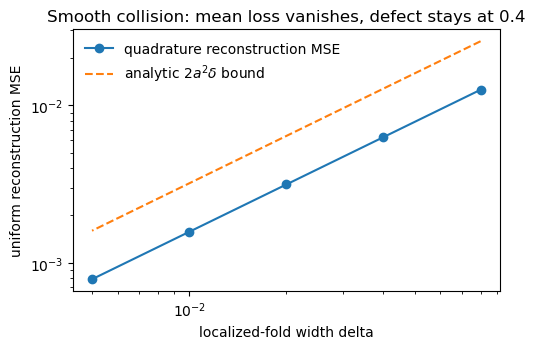

{'smooth_encoder_collision_margin': 0.4,
 'smallest_width': 0.005,
 'smallest_quadrature_mse': 0.0007866849832056012,
 'analytic_bound_at_smallest_width': 0.0016000000000000003,
 'latent_identity_dynamics_prediction_mse': 0.0,
 'action_required_violation': 0.4}

In [10]:
collision_margin = 0.4
widths = np.asarray([0.08, 0.04, 0.02, 0.01, 0.005])
quadrature_states = np.linspace(-1.0, 1.0, 40_001, endpoint=True)
smooth_mse = []
smooth_bounds = []
for width in widths:
    codes = np.asarray([
        localized_collision_encoder(
            float(state), collision_margin=collision_margin, width=float(width)
        )
        for state in quadrature_states
    ])
    smooth_mse.append(float(np.mean((quadrature_states - codes) ** 2)))
    smooth_bounds.append(localized_collision_mse_bound(
        collision_margin=collision_margin, width=float(width)
    ))
    assert np.isclose(localized_collision_encoder(
        collision_margin, collision_margin=collision_margin, width=float(width)
    ), 0.0)
    assert np.isclose(localized_collision_encoder(
        -collision_margin, collision_margin=collision_margin, width=float(width)
    ), 0.0)

smooth_action = audit_exact_action_fibers(
    [(0.0,), (0.0,)],
    [signed_action_margins(collision_margin), signed_action_margins(-collision_margin)],
)
assert np.all(np.asarray(smooth_mse) <= np.asarray(smooth_bounds) * 1.001)
assert smooth_action.conflicting_fiber_count == 1
assert np.isclose(smooth_action.worst_required_violation, collision_margin)

fig, axis = plt.subplots(figsize=(5.2, 3.6))
axis.loglog(widths, smooth_mse, marker="o", label="quadrature reconstruction MSE")
axis.loglog(widths, smooth_bounds, linestyle="--", label=r"analytic $2a^2\delta$ bound")
axis.set(xlabel="localized-fold width delta", ylabel="uniform reconstruction MSE")
axis.set_title("Smooth collision: mean loss vanishes, defect stays at 0.4")
axis.legend(frameon=False)
fig.tight_layout()
plt.show()

display({
    "smooth_encoder_collision_margin": collision_margin,
    "smallest_width": float(widths[-1]),
    "smallest_quadrature_mse": smooth_mse[-1],
    "analytic_bound_at_smallest_width": smooth_bounds[-1],
    "latent_identity_dynamics_prediction_mse": 0.0,
    "action_required_violation": smooth_action.worst_required_violation,
})

## 7. Visual audit and theorem-check summary

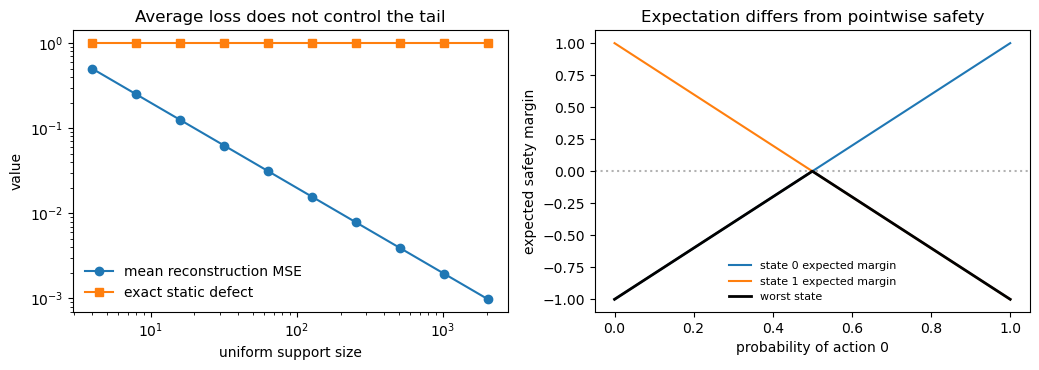

{
  "action_conflict_detected": true,
  "average_loss_counterexample_verified": true,
  "common_prior_kl_lower_bound_checked": true,
  "data_processing_cases": 648,
  "data_processing_violations": 0,
  "deterministic_one_hot_reductions": 81,
  "finite_action_lp_trials": 100,
  "interval_helly_trials": 500,
  "interval_helly_violations": 0,
  "near_one_tv_support_overlap_detected": true,
  "planar_halfspace_full_slack": 0.29289321881345254,
  "planar_halfspace_pairs_feasible": true,
  "smooth_population_counterexample_verified": true,
  "static_equivalence_cases": 648,
  "stochastic_action_tradeoff_cases": 81,
  "stochastic_closed_certificate_cases": 486,
  "stochastic_data_processing_cases": 243,
  "stochastic_open_certificate_cases": 486,
  "stochastic_tv_error_pairs": 36,
  "strong_randomized_equals_deterministic": true,
  "zero_endpoint_cases_distinguished": true
}


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
axes[0].loglog(support_sizes, average_losses, marker="o", label="mean reconstruction MSE")
axes[0].plot(support_sizes, worst_defects, marker="s", label="exact static defect")
axes[0].set(xlabel="uniform support size", ylabel="value")
axes[0].set_title("Average loss does not control the tail")
axes[0].legend(frameon=False)

axes[1].plot(q_action_zero, expected_by_state[0], label="state 0 expected margin")
axes[1].plot(q_action_zero, expected_by_state[1], label="state 1 expected margin")
axes[1].plot(q_action_zero, worst_expected_margin, color="black", linewidth=2, label="worst state")
axes[1].axhline(0.0, color="black", alpha=0.3, linestyle=":")
axes[1].set(xlabel="probability of action 0", ylabel="expected safety margin")
axes[1].set_title("Expectation differs from pointwise safety")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

checks = {
    "static_equivalence_cases": frontier_cases,
    "data_processing_cases": data_processing_cases,
    "data_processing_violations": 0,
    "stochastic_closed_certificate_cases": stochastic_closed_certificate_cases,
    "stochastic_open_certificate_cases": stochastic_open_certificate_cases,
    "deterministic_one_hot_reductions": deterministic_reduction_cases,
    "stochastic_tv_error_pairs": stochastic_tv_error_cases,
    "stochastic_data_processing_cases": stochastic_data_processing_cases,
    "stochastic_action_tradeoff_cases": stochastic_action_tradeoff_cases,
    "near_one_tv_support_overlap_detected": not near_one_tv_point.mutually_singular,
    "common_prior_kl_lower_bound_checked": kl_pair_error + 1e-15 >= kl_lower_bound,
    "zero_endpoint_cases_distinguished": True,
    "action_conflict_detected": action_audit.conflicting_fiber_count == 1,
    "finite_action_lp_trials": finite_action_trials,
    "strong_randomized_equals_deterministic": hard_slacks[2] == hard_slacks[0],
    "interval_helly_trials": interval_helly_trials,
    "interval_helly_violations": 0,
    "planar_halfspace_pairs_feasible": True,
    "planar_halfspace_full_slack": planar_full_slack,
    "average_loss_counterexample_verified": set(worst_defects) == {1.0},
    "smooth_population_counterexample_verified": bool(
        smooth_action.conflicting_fiber_count == 1
        and np.all(np.asarray(smooth_mse) <= np.asarray(smooth_bounds) * 1.001)
    ),
}
print(json.dumps(checks, indent=2, sort_keys=True))

## Takeaways and proof obligations that remain

The deterministic and stochastic finite oracles agree with brute-force certificate enumeration,
the one-hot reduction, and exhaustive Markov data-processing checks. The interval regression
confirms the one-dimensional pair reduction, while the analytic three-halfspace example shows that
pairwise feasibility is insufficient in two action dimensions. The endpoint, randomization, and
average-loss examples should be retained because each blocks a tempting overstatement.

This does **not** close the population theory. Remaining obligations include the treatment of
non-attained suprema, measurability/selection for positive action results, continuous action spaces,
uncountable stochastic state families, approximate latent neighborhoods, and a certified way to
compute population violation scores. The source of novelty is also not the maximal pure-safe latent
set itself; the paper must distinguish its quantitative/action/partial-observability results from
prior latent-safe set work.